In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/23_Trees/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


#EDA

<Axes: xlabel='class', ylabel='count'>

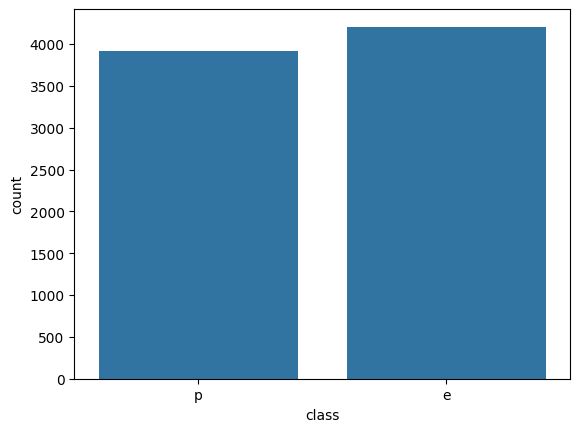

In [4]:
sns.countplot(data=df,x='class')

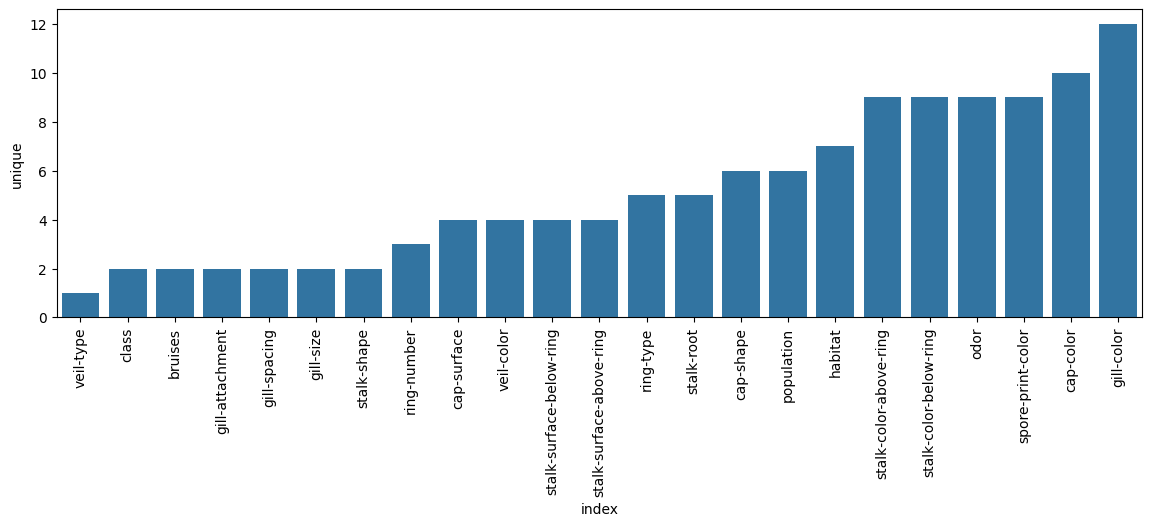

In [9]:
des = df.describe().transpose().reset_index().sort_values('unique')


plt.figure(figsize=(14,4))
sns.barplot(data=des,x='index',y='unique')
plt.xticks(rotation=90)
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

# Train | Test Split

In [11]:
X = df.drop('class',axis=1)
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [13]:
X = pd.get_dummies(X,drop_first=True)
y = df['class']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15, random_state=101)

In [16]:
from sklearn.ensemble import AdaBoostClassifier

In [17]:
model = AdaBoostClassifier(n_estimators=1)

In [18]:
model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=1)

# Model Evaluation

In [19]:
from sklearn.metrics import classification_report, accuracy_score

In [20]:
pred = model.predict(X_test)

In [21]:
pred

array(['p', 'e', 'p', ..., 'p', 'p', 'e'], dtype=object)

In [22]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           e       0.96      0.81      0.88       655
           p       0.81      0.96      0.88       564

    accuracy                           0.88      1219
   macro avg       0.88      0.88      0.88      1219
weighted avg       0.89      0.88      0.88      1219



In [23]:
model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [24]:
model.feature_importances_.argmax()

np.int64(22)

In [26]:
X.columns[22]

'odor_n'

<Axes: xlabel='odor', ylabel='count'>

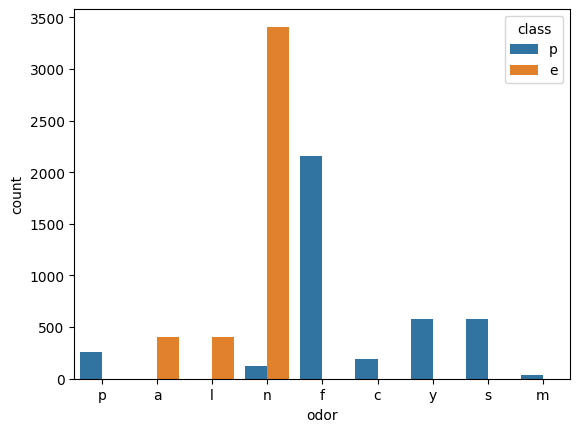

In [27]:
sns.countplot(data=df,x='odor',hue='class')

# Analyzing Performance as more stumps are added

In [29]:
error_rates = []


for n in range(1,96):
  model = AdaBoostClassifier(n_estimators=n)
  model.fit(X_train,y_train)
  pred = model.predict(X_test)
  err = 1-accuracy_score(y_test,pred)
  error_rates.append(err)

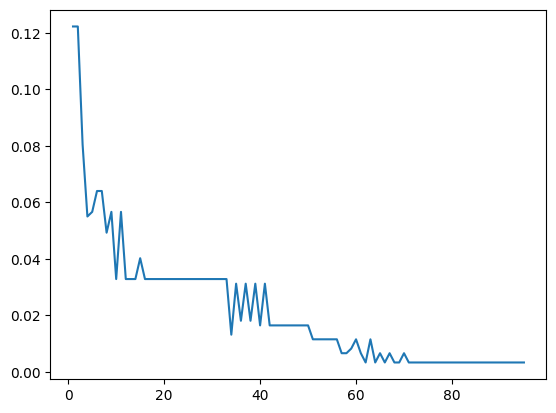

In [30]:
plt.plot(range(1,96),error_rates)

In [31]:
model

AdaBoostClassifier(n_estimators=95)

In [34]:
feats = pd.DataFrame(data = model.feature_importances_, index=X.columns, columns = ['Important Features'])

In [36]:
imp_feat = feats[feats['Important Features']>0]

<Axes: >

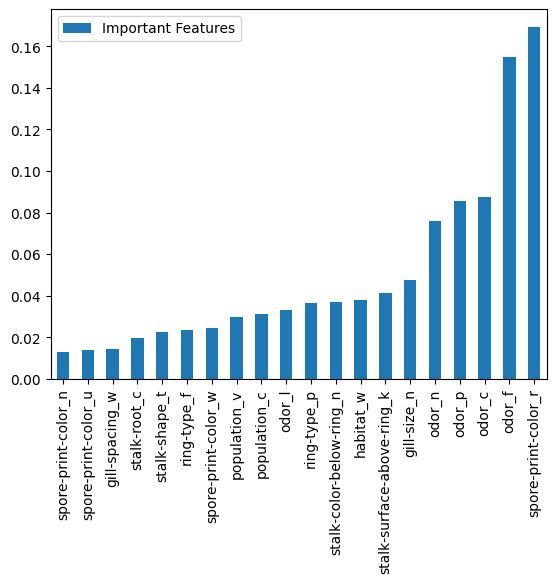

In [39]:
imp_feat.sort_values('Important Features').plot(kind='bar')

# Gradient Boosting and Grid Search with CV

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

In [41]:
param_grid = {'n_estimators':[1,5,10,20,40,100],
              'max_depth':[3,4,5,6]}

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
gb_model = GradientBoostingClassifier()

In [44]:
grid = GridSearchCV(gb_model,param_grid)

# Fit to Training Data with CV Search

In [45]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'n_estimators': [1, 5, 10, 20, 40, 100]})

In [46]:
grid.best_params_

{'max_depth': 3, 'n_estimators': 100}

In [47]:
predictions = grid.predict(X_test)

In [48]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       655
           p       1.00      1.00      1.00       564

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



In [51]:
feat_importance = grid.best_estimator_.feature_importances_

In [54]:
imp_feats = pd.DataFrame(index=X.columns,data=feat_importance,columns=['Importance'])
imp_feats.sort_values('Importance',ascending=False)

,Importance
odor_n,0.614744
stalk-root_c,0.135973
bruises_t,0.051593
stalk-root_r,0.044753
spore-print-color_r,0.030495
...,...
spore-print-color_y,0.000000
population_n,0.000000
habitat_l,0.000000
habitat_p,0.000000


<Axes: >

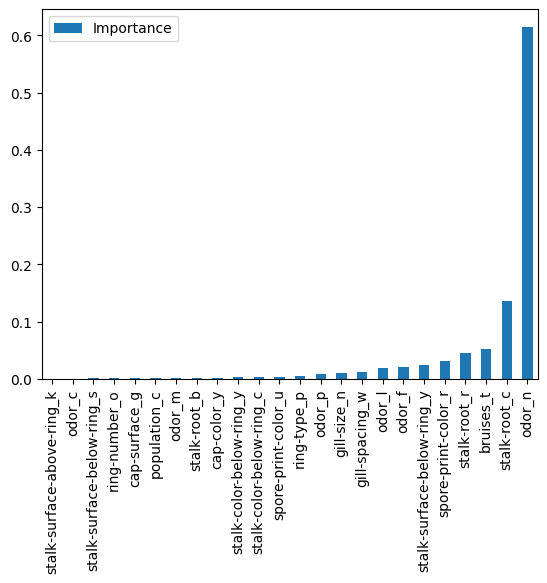

In [59]:
imp_feats = imp_feats[imp_feats['Importance']>0.0003]

imp_feats.sort_values('Importance').plot(kind='bar')